<div style="display: flex; align-items: center; padding: 20px; background-color: #f0f2f6; border-radius: 10px; border: 2px solid #007bff;">
    <img src="../logo.png" style="width: 80px; height: auto; margin-right: 20px;">
    <div style="flex: 1; text-align: left;">
    <h1 style="color: #007bff; margin-bottom: 5px;">GLY 6739.017S26: Computational Seismology</h1>
    <h3 style="color: #666;">Notebook 160: Reduced Displacement</h3>
    <p style="color: red;"><i>Glenn Thompson | Spring 2026</i></p>
    </div>
</div>


# Reduced Displacement notebook

In this tutorial, we will explore Reduced Displacement ($D_R$) data, which is a useful approximate measurement for comparing the sizes of different volcanic eruptions.

Seismometers are (usually) velocity transducers - they generate an electric signal (in Volts) that is proportional to the velocity of ground shaking within a certain passband. Outside that passband, the seismometer no longer generates a voltage proportional to ground velocity. This voltage signal has to be digitized (using an analog-to-digital converter built into the datalogger or on a computer at the observatory), converting the signal units from Volts to digitizer "Counts" before it can be examined on a computer. This is a raw seismic signal. To convert this raw seismic signal to a velocity seismogram, we must "remove the instrument response". Then by carefully integrating the velocity seismogram, we will have a displacement seismogram. So we have raw, velocity, and displacement, seismograms.

RSAM is just one of several related downsampled seismic measurements. Some others supported by the `SAM` package are:

<table>
    <tr><th>Acronym</th><th>Full name</th><th>Computed from a:</th><th>Instrument corrected?</th><th>Geometrically corrected?</th></tr>
    <tr><td>RSAM</td><td><b>Real-time (or Raw) Seismic Amplitude Measurement</b></td><td>Raw seismogram</td><td>N</td><td>N</td></tr>
    <tr><td>VSAM</td><td>Velocity Seismic Amplitude Measurement</td><td>Velocity seismogram</td><td>Y</td><td>N</td></tr>
    <tr><td>DSAM</td><td>Displacement Seismic Amplitude Measurement</td><td>Displacement seismogram</td><td>Y</td><td>N</td></tr>
    <tr><td>RSEM</td><td>Raw Seismic Energy Measurement</td><td>Raw seismogram</td><td>N</td><td>N</td></tr>   
    <tr><td>VSEM</td><td>Velocity Seismic Energy Measurement</td><td>Velocity seismogram</td><td>Y</td><td>N</td></tr>
    <tr><td>$V_R$ and $V{_{RS}}$</td><td>Reduced Velocity</td><td>VSAM</td><td>Y</td><td>Y</td></tr>  
    <tr><td>$D{_R}$ and $D_{RS}$</td><td><b>Reduced Displacement</b></td><td>DSAM</td><td>Y</td><td>Y</td></tr>   
    <tr><td>$E_R$</td><td><b>Reduced Energy</b></td><td>VSEM</td><td>Y</td><td>Y</td></tr>     
</table>

## 1. Correcting for Geometrical Spreading

How do we compare seismograms recorded at different distances from the same volcano? Or from different volcanoes? One thing we can do is to "reduce" the seismograms to a common distance, e.g. 1 km, by correcting for geometrical spreading. This is the idea behind Reduced Displacement. 

Consider a simple half-space velocity model of uniform density. As body waves propagate to greater distances, the wavefront can be thought of as a hemispherical shell, with surface area $2\pi{r}^2$. If energy is not dissipated inelastically or scattered, the energy per unit area must then diminish $1/{r}^2$. And since amplitude is proportional to the square root of energy, the amplitude of body waves diminishes like 1/r. We call this "geometrical spreading".

Similarly, surface waves can be thought of as a circular (or cylindrical) wavefront, whose circumference increases like $2\pi r$, so energy density diminishes like 1/r and surface wave amplitude as $1/\sqrt(r)$.

Reduced Displacement was introduced by Aki & Koyanagi (1981) as a measurement of volcanic tremor amplitude for Kilaeua. Proportional to seismic moment rate, it is the RMS amplitude of a displacement seismogram, corrected for geometrical spreading. 

For body waves:

$D_{R} = rms(U) r$

where r = distance from source to station, U = displacement

Beyond a few wavelengths, surface waves dominate, and Fehler (1983) determined:

$D_{RS} = rms(U) \sqrt{r \lambda}$

In a series of papers McNutt (1994; 2005; 2008) demonstrated scaling relationships for explosive volcanic eruptions between Reduced Displacement and:
- ash column height
- Volcanic Explosivity Index (Newhall and Self, 1982)
- cross-sectional area of volcanic vent

RSAM is generally more useful for seismic field engineers, because it is unfiltered. Reduced Displacement is generally more useful for scientists, as it is a measurement that can be compared from station to station, even on different volcanoes. 

References:

- Aki, K., Koyanagi, R.Y., 1981. Deep volcanic tremor and magma ascent mechanism under Kilauea, Hawaii. J. Geophys. Res. 86, 7095–7110.
- Fehler, M., 1983. Observations of volcanic tremor at Mount St. Helens Volcano. J. Geophys. Res. 88, 3476–3484.
- McNutt, S.R., 1994. Volcanic tremor amplitude correlated with the Volcanic Explosivity Index and its potential use in determining ash hazards to aviation. Acta Vulcanol. 5, 193–196.
- McNutt, S.R., Nishimura, T., 2008. Volcanic tremor during eruptions: Temporal characteristics, scaling and constraints on conduit size and processes. J. Volcanol. Geotherm. Res., 178, 1, 10-18. https://doi.org/10.1016/j.jvolgeores.2008.03.010.
- Newhall, C.G., Self, S., 1982. The volcanic explosivity index (VEI): an estimate of explosive magnitude for historical volcanism. J. Geophys. Res. 87, 1231–1238.

## 2. Computing Reduced Displacement

### 2.1 Algorithm

DSAM is just an instrument-corrected version of RSAM, and $D_R$/$D_{RS}$  is just DSAM corrected for geometrical spreading, and so SAM.py was written to support all these different measurements. Here is an algorithm:

1. Load raw seismic data as an ObsPy Stream object.
2. Load station/instrument response metadata from a StationXML file into an Obspy Inventory object.
3. Remove instrument response to convert Stream object to a displacement seismogram.
4. Compute DSAM data from this displacement seismogram. 
6. Define a fixed source location.
7. Compute distance from station to source (done internally using source and inventory)
8. "Reduce" the DSAM object by multiplying by geometrical spreading correction.

### 2.2 From the RSAM notebook

In [1]:
import sys
sys.path.append('../week8') # this is where set_samba_data_root.py lives
from set_samba_data_root import DATA_ROOT # this sets DATA_ROOT to the path of the samba share on your system

# -----------------------------------------------------------------------------
# Input directory for SDS data
# -----------------------------------------------------------------------------
# Expand "~" to your home directory and create the folder if it doesn't exist
from pathlib import Path
#SDS_MVO_ROOT = DATA_ROOT / "SDS_MVO"
SDS_MVO_ROOT = Path('~').expanduser() / 'work' / 'SDS'

# -----------------------------------------------------------------------------
# Output directory for DSAM (SAM) data
# -----------------------------------------------------------------------------
# Expand "~" to your home directory and create the folder if it doesn't exist
SAM_DIR = Path('~').expanduser() / 'work' / 'sam_data'
SAM_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# Initialize SDS client (points to your SDS archive on disk)
# -----------------------------------------------------------------------------

from flovopy.enhanced.sdsclient import EnhancedSDSClient
mySDSclient = EnhancedSDSClient(SDS_MVO_ROOT)


1 Trace(s) in Stream:
MV.MBLG..SHZ | 2003-07-13T00:00:00.000000Z - 2003-07-13T23:59:59.986667Z | 75.0 Hz, 6480000 samples


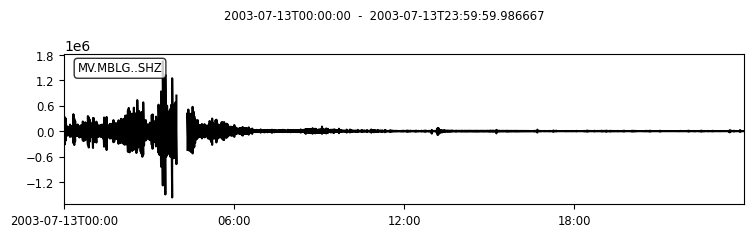

In [2]:
from obspy import read, read_inventory, UTCDateTime
from flovopy.processing.sam import DSAM

RESPONSE_DIR = DATA_ROOT / 'SEISAN_DB' / 'CAL'

mseedfile = SDS_MVO_ROOT / '2003' / 'MV' / 'MBLG' / 'SHZ.D' / 'MV.MBLG.--.SHZ.D.2003.194'
st = read(mseedfile, format='MSEED')
print(st)
st.plot();


In [3]:
from obspy import read_inventory
#from flovopy.processing.sam import DSAM

# load instrument response, remove instrument response from seismogram
stationxml = RESPONSE_DIR / 'MV.xml'
inv = read_inventory(stationxml)

# Set pre-filter for response removal. Remember this is a bandpass applied directly in the frequency domain
pre_filt = [0.1, 0.2, 18, 25]

### Try instrument correction

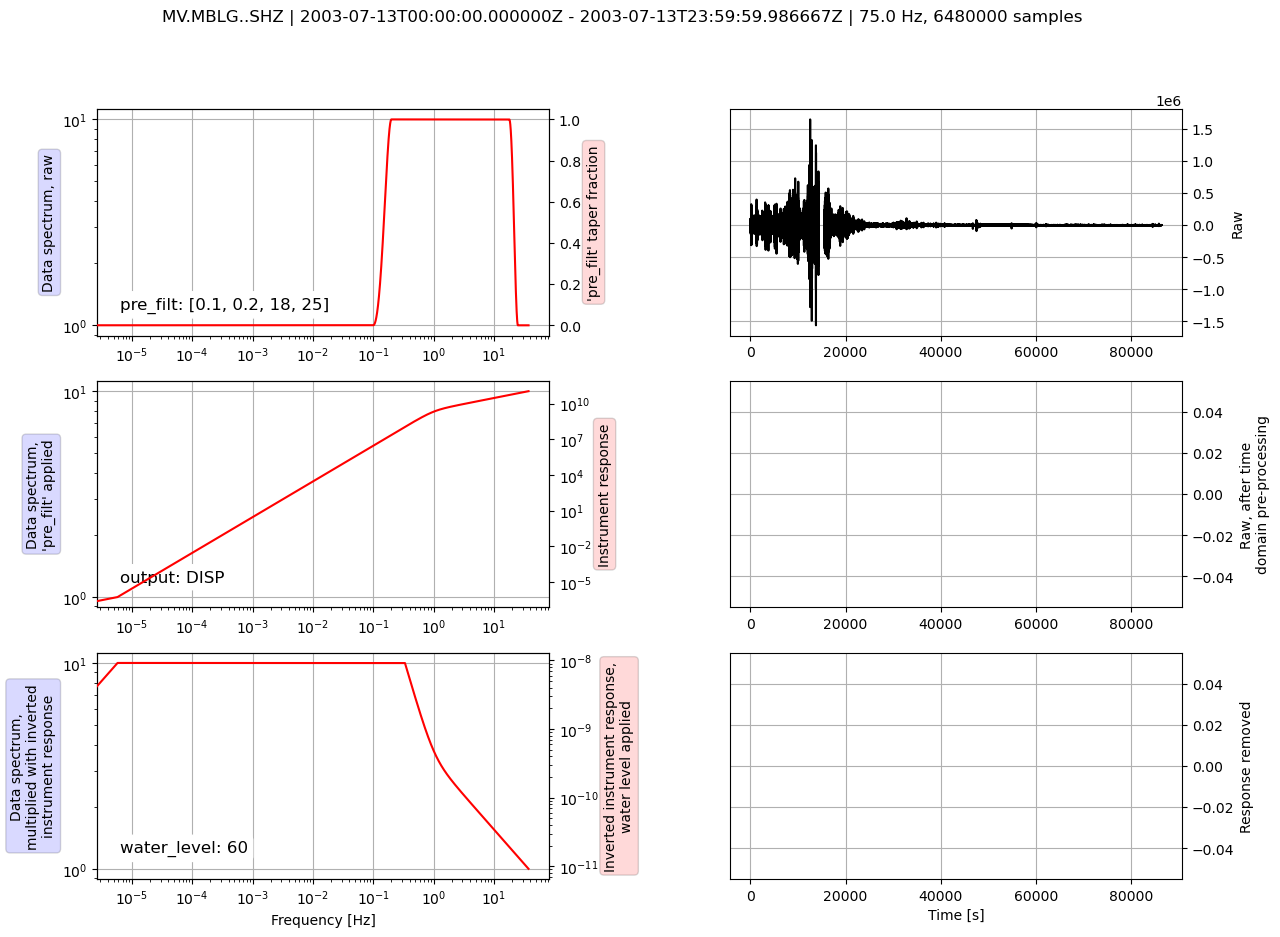

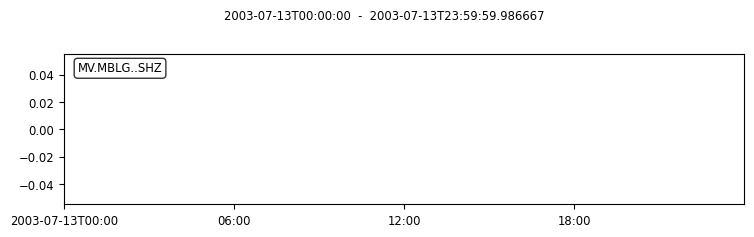

In [4]:
st2 = st.copy()
st2.remove_response(inventory=inv, pre_filt=pre_filt, output="DISP", plot=True) 
st2.plot();

That did not work because the Trace.data had NaN (Not-a-Number) in it marking data gaps. And filtering operations will turn anything with NaN in to a numpy array of all NaN. So we need to replace them with a suitable value, such as 0.

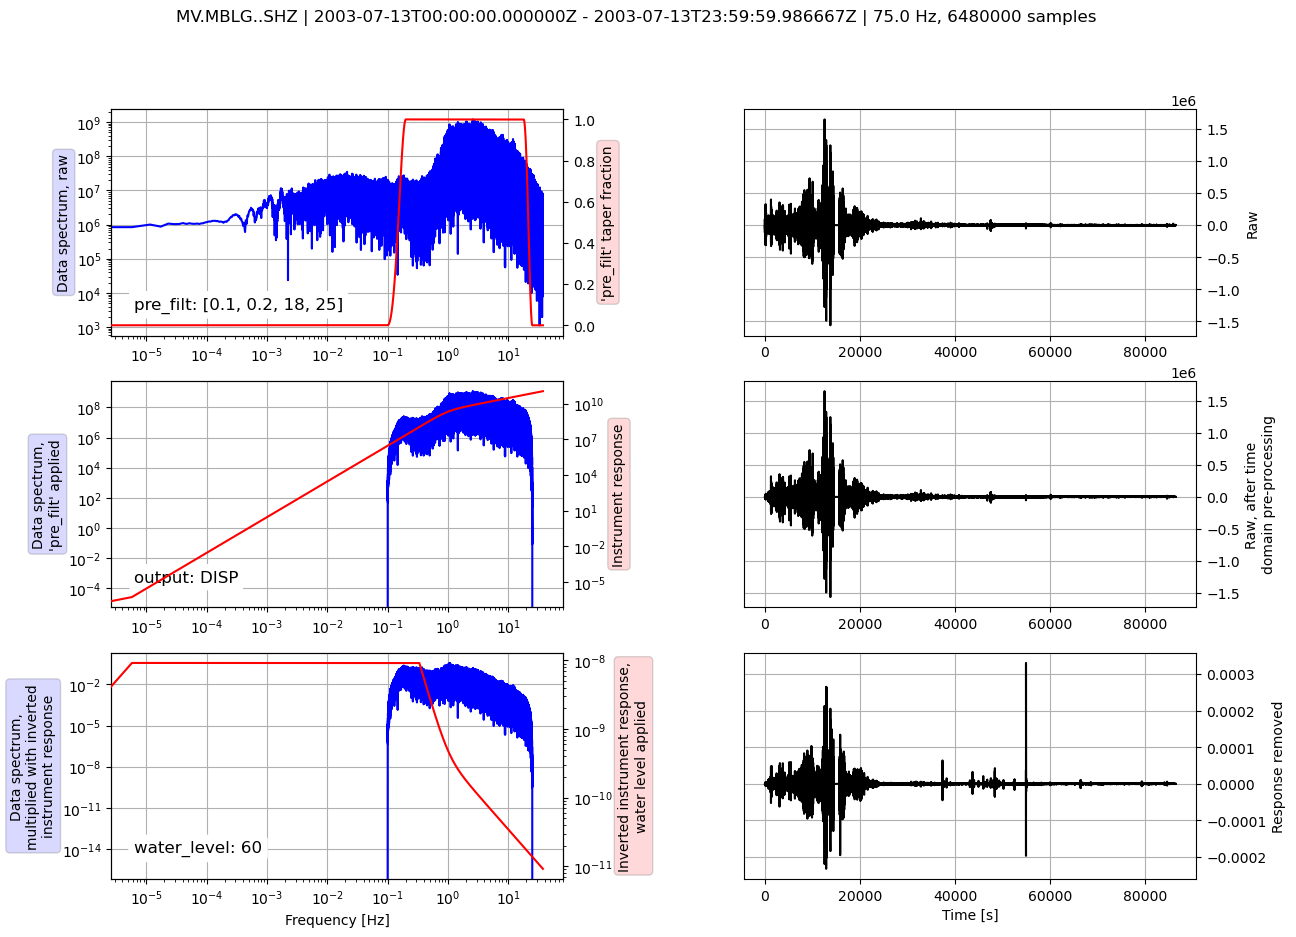

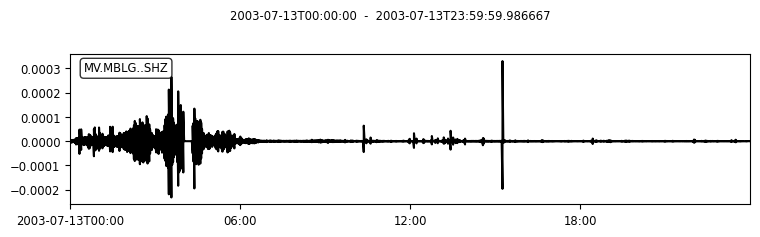

In [5]:
import numpy as np
st2 = st.copy()
for tr in st2:
    tr.data = np.nan_to_num(tr.data, nan=0) # Ensure data is in float64 format for remove_response
st2.remove_response(inventory=inv, pre_filt=pre_filt, output="DISP", plot=True) 
st2.plot();

### Compute DSAM & $D{_R}$

SCAFFOLD: Inventory created at 2024-01-11T03:20:26.394930Z
	Created by: ObsPy 1.4.0
		    https://www.obspy.org
	Sending institution: ObsPy's obspy.io.xseed version 1.2.2
	Contains:
		Networks (54):
			MV (54x)
		Stations (75):
			MV.MBBE () (3x)
			MV.MBBY () (6x)
			MV.MBFL () (3x)
			MV.MBFR () (3x)
			MV.MBGA () (3x)
			MV.MBGB () (6x)
			MV.MBGE () (3x)
			MV.MBGH () (9x)
			MV.MBHA () (3x)
			MV.MBLG () (6x)
			MV.MBLY () (6x)
			MV.MBMH () (3x)
			MV.MBRV () (3x)
			MV.MBRY () (9x)
			MV.MBSS () (3x)
			MV.MBWH () (6x)
		Channels (75):
			MV.MBBE..BHZ, MV.MBBE..BHN, MV.MBBE..BHE, MV.MBBY..BHZ, 
			MV.MBBY..BHN, MV.MBBY..BHE, MV.MBBY..HHZ, MV.MBBY..HHN, 
			MV.MBBY..HHE, MV.MBFL..EHZ, MV.MBFL..EHN, MV.MBFL..EHE, 
			MV.MBFR..HHZ, MV.MBFR..HHN, MV.MBFR..HHE, MV.MBGA..BHZ, 
			MV.MBGA..BHN, MV.MBGA..BHE, MV.MBGB..BHZ, MV.MBGB..BHN, 
			MV.MBGB..BHE, MV.MBGB..HHZ, MV.MBGB..HHN, MV.MBGB..HHE, 
			MV.MBGE..BHZ, MV.MBGE..BHN, MV.MBGE..BHE, MV.MBGH..BHZ, 
			MV.MBGH..BHN, MV.MBGH..BHE, 

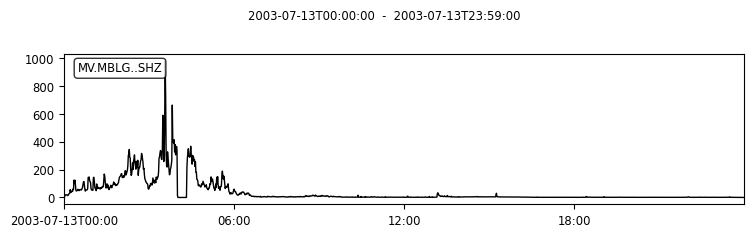

In [6]:

#################################################
# So far we just have a displacement seismogram
#################################################

# Generate a Displacement Seismic Amplitude Measurement (DSAM) object - units must be 'm' else will not work
dsamObj = DSAM(stream=st2, sampling_interval=60)

# Define a source location for Soufriere Hills volcano. Station distances to this lat/lon are used to "reduce" the displacement to 1 km distance.
source = {'lat':16.7164, 'lon':-62.1654}  

# Generate a Reduced Displacement object, assuming body waves (surfaceWaves=False) and no inelastic attenuation (Q=None)
DRobj = dsamObj.compute_reduced_displacement(inv, source, surfaceWaves=False, Q=None)
DRobj.plot()


The units of $D_R$ and $D_{RS}$ objects are ${cm}^2$.

They have the same metrics (columns in the DataFrame) as an RSAM object:

In [7]:
# Columns
print(DRobj.metrics)

['min', 'mean', 'max', 'median', 'rms', 'VLP', 'LP', 'VT', 'fratio']


## 3. Comparing the Reduced Displacement of several eruptions

1-minute DSAM data have been pre-computed for several eruptions. We will now load these, compute $D_R$ (and $D_RS$), and compare them. The general syntax we will use to read DSAM data and compute $D_R$ (and $D_{RS}$)  is:

```
dsamObj = DSAM.read(startTime, endTime, SAM_DIR='/path/to/DSAM/data/directory', sampling_interval=sampling_interval, ext=ext)
DRobj = dsamObj.compute_reduced_displacement(inventory, source, surfaceWaves=False, Q=None)
```
We will capture the highest $D_R$ (and $D_{RS}$) into a results DataFrame, resultsDF.

For reasons that will become clearer later, we will compute $D_{RS}$ in two frequency bands. The default is 0.5-18.0 Hz, the standard one we used for computing RSAM data previously. The second is a VLP passband, from 0.02 to 0.2 Hz. We write a function, compute_reduced_displacements, so we don't have to keep repeating the same code block:

In [ ]:
import pandas as pd
resultsDF = pd.DataFrame(columns=['Event', 'DR', 'DRS', 'DRS_VLP'])

SAM_DIR = DATA_ROOT / 'SAM'

def compute_reduced_displacements(eventname, dsamObj, source, stationxml, resultsDF, surfaceWaveSpeed_kms=2.0, peakf=None):

    dsamObj = dsamObj.select(component='Z')
    inv = read_inventory(stationxml)
    
    # body wave reduced displacement
    print('Computing body-wave DR')
    DRobj = dsamObj.compute_reduced_displacement(inv, source, surfaceWaves=False, Q=None, wavespeed_kms=surfaceWaveSpeed_kms, peakf=peakf)
    print('Plotting body-wave DR')
    DRobj.plot(metrics='rms')
    DRmaxrms = DRobj.max(metric='rms')
    
    # surface wave reduced displacement
    print('Computing surface-wave DRS')
    DRSobj = dsamObj.compute_reduced_displacement(inv, source, surfaceWaves=True, Q=None, wavespeed_kms=surfaceWaveSpeed_kms, peakf=peakf)
    #DRSobj.plot(metrics='rms')   
    DRSmaxrms = DRSobj.max(metric='rms')

    print('Computing surface-wave DRS in the VLP band')
    DRSobjBB = DRSobj.select(channel='[BH]HZ')
    if len(DRSobjBB)>0:
        DRSmaxvlp = DRSobjBB.max(metric='VLP')
    else:
        #sumE_VLP, ME_VLP = ERobj.sum_energy(metric='VLP')
        DRSmaxvlp  = 0
    
    # add to results
    resultsDF.loc[len(resultsDF.index)] = [eventname, DRmaxrms, DRSmaxrms, DRSmaxvlp]
    

### 3.1 Event 1: Boxing Day Collapse 1997, Montserrat

29 months into the eruption of the Soufriere Hills Volcano, Montserrat, part of the crater wall the lava dome was growing within (and overtopping) suddenly collapsed in a landslide, causing a sideways explosion of the lava dome which effectively removed all traces of villages in the southwest quadrant of Montserrat (the villages had been evacuated more than a year earlier). At this time, there were only 2 stations operational, due to months of pyroclastic flows which had destroyed the capital, Plymouth, the airport, numerous other villages, and several seismic stations, and it was much too dangerous to replace them.

All vertical-component traces:
4 Trace(s) in Stream:
MV.MBBE..BHZ | 1997-12-24T18:00:00.000000Z - 1997-12-24T19:02:43.026667Z | 75.0 Hz, 282228 samples
MV.MBGA..BHZ | 1997-12-25T00:22:43.040000Z - 1997-12-25T00:42:43.026667Z | 75.0 Hz, 90000 samples
MV.MBWH..SHZ | 1997-12-24T18:00:00.000000Z - 1997-12-27T06:00:00.000000Z | 75.0 Hz, 16200001 samples (masked)
MV.MBLG..SHZ | 1997-12-24T18:42:43.040000Z - 1997-12-27T06:00:00.000000Z | 75.0 Hz, 16007773 samples (masked)
Subset containing only SHZ traces:
2 Trace(s) in Stream:
MV.MBWH..SHZ | 1997-12-24T18:00:00.000000Z - 1997-12-27T06:00:00.000000Z | 75.0 Hz, 16200001 samples (masked)
MV.MBLG..SHZ | 1997-12-24T18:42:43.040000Z - 1997-12-27T06:00:00.000000Z | 75.0 Hz, 16007773 samples (masked)
Plot of corrected waveforms (displacement in metres):


/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  plt.setp(ax.get_xticklabels(), fontsize='small',


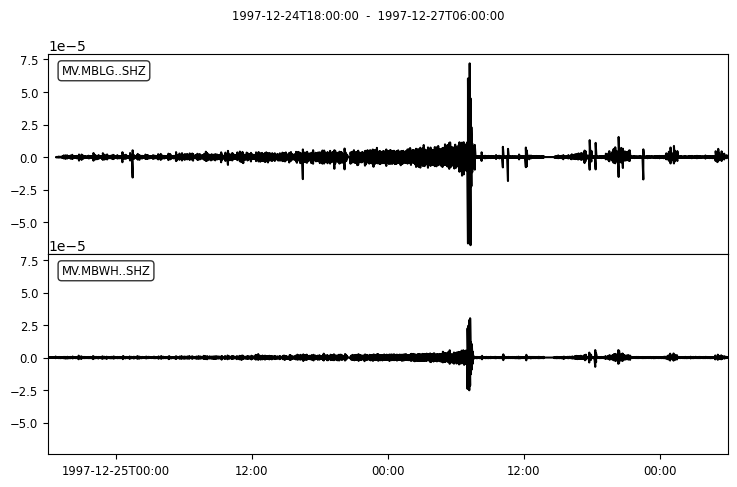

Computing body-wave DR
SCAFFOLD: Inventory created at 2024-01-11T03:20:26.394930Z
	Created by: ObsPy 1.4.0
		    https://www.obspy.org
	Sending institution: ObsPy's obspy.io.xseed version 1.2.2
	Contains:
		Networks (54):
			MV (54x)
		Stations (75):
			MV.MBBE () (3x)
			MV.MBBY () (6x)
			MV.MBFL () (3x)
			MV.MBFR () (3x)
			MV.MBGA () (3x)
			MV.MBGB () (6x)
			MV.MBGE () (3x)
			MV.MBGH () (9x)
			MV.MBHA () (3x)
			MV.MBLG () (6x)
			MV.MBLY () (6x)
			MV.MBMH () (3x)
			MV.MBRV () (3x)
			MV.MBRY () (9x)
			MV.MBSS () (3x)
			MV.MBWH () (6x)
		Channels (75):
			MV.MBBE..BHZ, MV.MBBE..BHN, MV.MBBE..BHE, MV.MBBY..BHZ, 
			MV.MBBY..BHN, MV.MBBY..BHE, MV.MBBY..HHZ, MV.MBBY..HHN, 
			MV.MBBY..HHE, MV.MBFL..EHZ, MV.MBFL..EHN, MV.MBFL..EHE, 
			MV.MBFR..HHZ, MV.MBFR..HHN, MV.MBFR..HHE, MV.MBGA..BHZ, 
			MV.MBGA..BHN, MV.MBGA..BHE, MV.MBGB..BHZ, MV.MBGB..BHN, 
			MV.MBGB..BHE, MV.MBGB..HHZ, MV.MBGB..HHN, MV.MBGB..HHE, 
			MV.MBGE..BHZ, MV.MBGE..BHN, MV.MBGE..BHE, MV.MBGH..BHZ, 
			MV.MB

/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  plt.setp(ax.get_xticklabels(), fontsize='small',


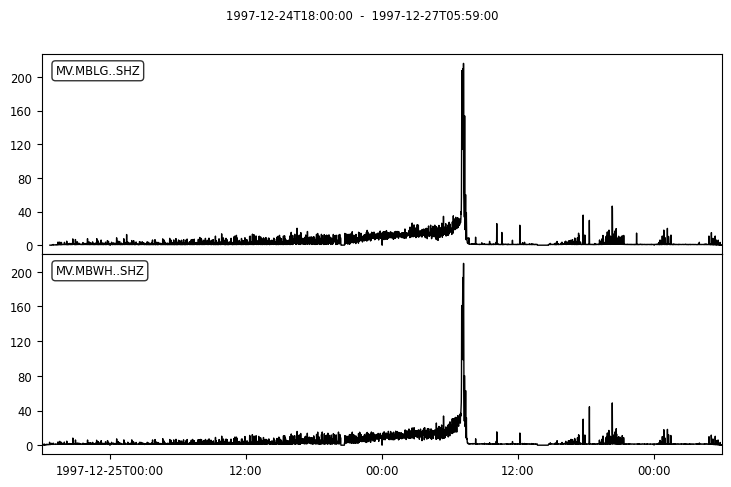

Computing surface-wave DRS
SCAFFOLD: Inventory created at 2024-01-11T03:20:26.394930Z
	Created by: ObsPy 1.4.0
		    https://www.obspy.org
	Sending institution: ObsPy's obspy.io.xseed version 1.2.2
	Contains:
		Networks (54):
			MV (54x)
		Stations (75):
			MV.MBBE () (3x)
			MV.MBBY () (6x)
			MV.MBFL () (3x)
			MV.MBFR () (3x)
			MV.MBGA () (3x)
			MV.MBGB () (6x)
			MV.MBGE () (3x)
			MV.MBGH () (9x)
			MV.MBHA () (3x)
			MV.MBLG () (6x)
			MV.MBLY () (6x)
			MV.MBMH () (3x)
			MV.MBRV () (3x)
			MV.MBRY () (9x)
			MV.MBSS () (3x)
			MV.MBWH () (6x)
		Channels (75):
			MV.MBBE..BHZ, MV.MBBE..BHN, MV.MBBE..BHE, MV.MBBY..BHZ, 
			MV.MBBY..BHN, MV.MBBY..BHE, MV.MBBY..HHZ, MV.MBBY..HHN, 
			MV.MBBY..HHE, MV.MBFL..EHZ, MV.MBFL..EHN, MV.MBFL..EHE, 
			MV.MBFR..HHZ, MV.MBFR..HHN, MV.MBFR..HHE, MV.MBGA..BHZ, 
			MV.MBGA..BHN, MV.MBGA..BHE, MV.MBGB..BHZ, MV.MBGB..BHN, 
			MV.MBGB..BHE, MV.MBGB..HHZ, MV.MBGB..HHN, MV.MBGB..HHE, 
			MV.MBGE..BHZ, MV.MBGE..BHN, MV.MBGE..BHE, MV.MBGH..BHZ, 
			M

/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  plt.setp(ax.get_xticklabels(), fontsize='small',


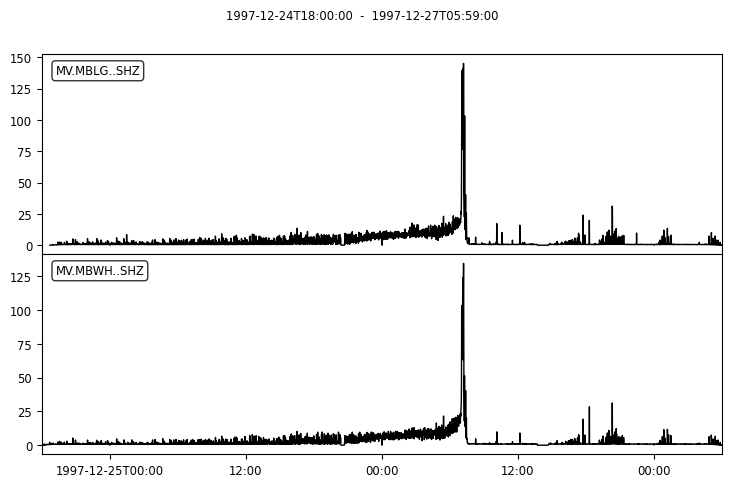

Computing surface-wave DRS in the VLP band


In [ ]:
# ------------------------------------------------------------
# 1. Define time window for the Boxing Day Collapse sequence
# ------------------------------------------------------------
from obspy import UTCDateTime, Stream, read_inventory
import numpy as np

startt1 = UTCDateTime(1997, 12, 24, 18, 0, 0)
endt1   = UTCDateTime(1997, 12, 27,  6, 0, 0)

eventname1 = "Boxing Day Collapse 1997"

# ------------------------------------------------------------
# 2. Read waveform data from the SDS archive
#    Here we request all vertical channels (*Z) for the time range
# ------------------------------------------------------------
mySDSclient = EnhancedSDSClient(SDS_MVO_ROOT)

st3 = mySDSclient.get_waveforms(
    network="MV",
    station="*",
    location="*",
    channel="*Z",
    starttime=startt1,
    endtime=endt1,
)

# Merge adjacent segments for each trace
st3.merge()

print("All vertical-component traces:")
print(st3)

# ------------------------------------------------------------
# 3. Keep only SHZ traces, as the BHZ traces are very incomplete
# ------------------------------------------------------------
st4 = Stream(traces=[tr for tr in st3 if tr.stats.channel == "SHZ"])

print("Subset containing only SHZ traces:")
print(st4)

# ------------------------------------------------------------
# 4. Read station metadata / instrument responses
# ------------------------------------------------------------
inv = read_inventory(stationxml)

# ------------------------------------------------------------
# 5. Clean data before instrument-response removal
#    remove_response() does not like NaN values, so replace them with 0
# ------------------------------------------------------------
for tr in st4:
    tr.data = np.nan_to_num(tr.data, nan=0.0)

# ------------------------------------------------------------
# 6. Remove instrument response to get displacement
#    output='DISP' gives displacement in metres
# ------------------------------------------------------------
st4.remove_response(
    inventory=inv,
    pre_filt=pre_filt,
    output="DISP",
)

# Quick check of corrected waveforms
print("Plot of corrected waveforms (displacement in metres):")
st4.plot()

# ------------------------------------------------------------
# 7. Build a DSAM object
#    sampling_interval=60 means 1-minute measurements
#    Units must be metres for DSAM -> reduced displacement workflow
# ------------------------------------------------------------
dsamObj = DSAM(
    stream=st4,
    sampling_interval=60,
)

# ------------------------------------------------------------
# 8. Define source location
#    Station distances to this source are used to reduce amplitudes
#    to a reference distance of 1 km
# ------------------------------------------------------------
source1 = {
    "lat": 16.71111,
    "lon": -62.17722,
}

# ------------------------------------------------------------
# 9. Call function defined above to compute reduced displacements
# ------------------------------------------------------------
compute_reduced_displacements(
    eventname1,
    dsamObj,
    source1,
    stationxml,
    resultsDF,
)

2 Trace(s) in Stream:
MV.MBLG..SHZ | 1997-12-24T18:42:43.040000Z - 1997-12-27T06:00:00.000000Z | 75.0 Hz, 16007773 samples (masked)
MV.MBWH..SHZ | 1997-12-24T18:00:00.000000Z - 1997-12-27T06:00:00.000000Z | 75.0 Hz, 16200001 samples (masked)
2 Trace(s) in Stream:
MV.MBLG..SHZ | 1997-12-24T18:42:43.040000Z - 1997-12-27T06:00:00.000000Z | 75.0 Hz, 16007773 samples (masked)
MV.MBWH..SHZ | 1997-12-24T18:00:00.000000Z - 1997-12-27T06:00:00.000000Z | 75.0 Hz, 16200001 samples (masked)


/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  plt.setp(ax.get_xticklabels(), fontsize='small',


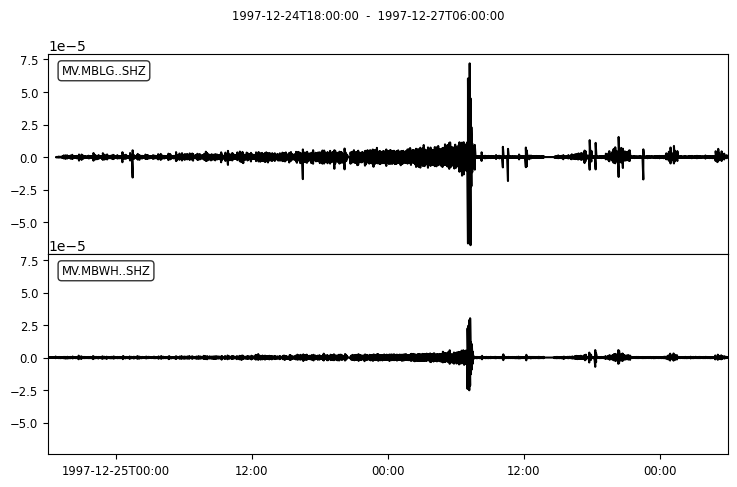

SCAFFOLD: Inventory created at 2024-01-11T03:20:26.394930Z
	Created by: ObsPy 1.4.0
		    https://www.obspy.org
	Sending institution: ObsPy's obspy.io.xseed version 1.2.2
	Contains:
		Networks (54):
			MV (54x)
		Stations (75):
			MV.MBBE () (3x)
			MV.MBBY () (6x)
			MV.MBFL () (3x)
			MV.MBFR () (3x)
			MV.MBGA () (3x)
			MV.MBGB () (6x)
			MV.MBGE () (3x)
			MV.MBGH () (9x)
			MV.MBHA () (3x)
			MV.MBLG () (6x)
			MV.MBLY () (6x)
			MV.MBMH () (3x)
			MV.MBRV () (3x)
			MV.MBRY () (9x)
			MV.MBSS () (3x)
			MV.MBWH () (6x)
		Channels (75):
			MV.MBBE..BHZ, MV.MBBE..BHN, MV.MBBE..BHE, MV.MBBY..BHZ, 
			MV.MBBY..BHN, MV.MBBY..BHE, MV.MBBY..HHZ, MV.MBBY..HHN, 
			MV.MBBY..HHE, MV.MBFL..EHZ, MV.MBFL..EHN, MV.MBFL..EHE, 
			MV.MBFR..HHZ, MV.MBFR..HHN, MV.MBFR..HHE, MV.MBGA..BHZ, 
			MV.MBGA..BHN, MV.MBGA..BHE, MV.MBGB..BHZ, MV.MBGB..BHN, 
			MV.MBGB..BHE, MV.MBGB..HHZ, MV.MBGB..HHN, MV.MBGB..HHE, 
			MV.MBGE..BHZ, MV.MBGE..BHN, MV.MBGE..BHE, MV.MBGH..BHZ, 
			MV.MBGH..BHN, MV.MBGH..BHE, 

/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  plt.setp(ax.get_xticklabels(), fontsize='small',


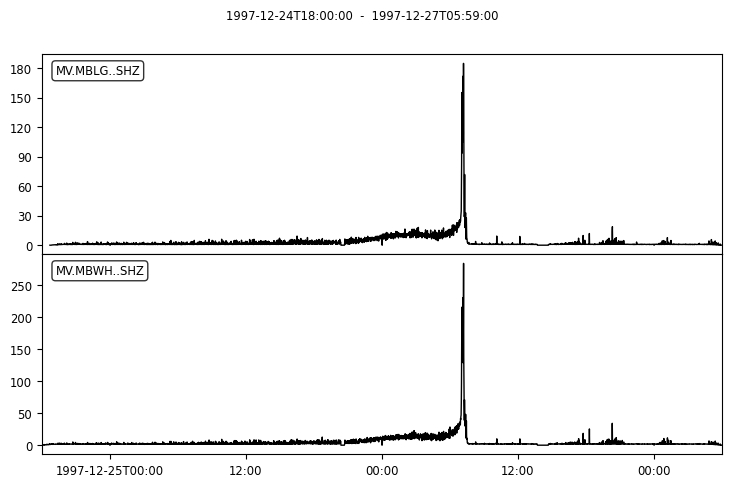

Computing body-wave DR
SCAFFOLD: Inventory created at 2024-01-11T03:20:26.394930Z
	Created by: ObsPy 1.4.0
		    https://www.obspy.org
	Sending institution: ObsPy's obspy.io.xseed version 1.2.2
	Contains:
		Networks (54):
			MV (54x)
		Stations (75):
			MV.MBBE () (3x)
			MV.MBBY () (6x)
			MV.MBFL () (3x)
			MV.MBFR () (3x)
			MV.MBGA () (3x)
			MV.MBGB () (6x)
			MV.MBGE () (3x)
			MV.MBGH () (9x)
			MV.MBHA () (3x)
			MV.MBLG () (6x)
			MV.MBLY () (6x)
			MV.MBMH () (3x)
			MV.MBRV () (3x)
			MV.MBRY () (9x)
			MV.MBSS () (3x)
			MV.MBWH () (6x)
		Channels (75):
			MV.MBBE..BHZ, MV.MBBE..BHN, MV.MBBE..BHE, MV.MBBY..BHZ, 
			MV.MBBY..BHN, MV.MBBY..BHE, MV.MBBY..HHZ, MV.MBBY..HHN, 
			MV.MBBY..HHE, MV.MBFL..EHZ, MV.MBFL..EHN, MV.MBFL..EHE, 
			MV.MBFR..HHZ, MV.MBFR..HHN, MV.MBFR..HHE, MV.MBGA..BHZ, 
			MV.MBGA..BHN, MV.MBGA..BHE, MV.MBGB..BHZ, MV.MBGB..BHN, 
			MV.MBGB..BHE, MV.MBGB..HHZ, MV.MBGB..HHN, MV.MBGB..HHE, 
			MV.MBGE..BHZ, MV.MBGE..BHN, MV.MBGE..BHE, MV.MBGH..BHZ, 
			MV.MB

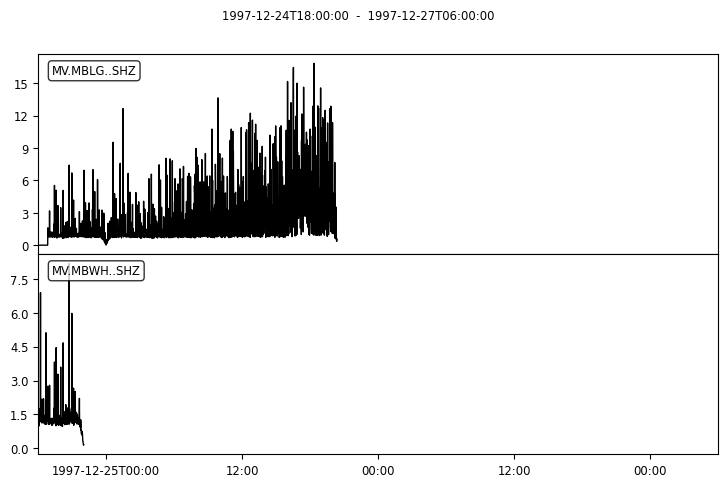

Computing surface-wave DRS
SCAFFOLD: Inventory created at 2024-01-11T03:20:26.394930Z
	Created by: ObsPy 1.4.0
		    https://www.obspy.org
	Sending institution: ObsPy's obspy.io.xseed version 1.2.2
	Contains:
		Networks (54):
			MV (54x)
		Stations (75):
			MV.MBBE () (3x)
			MV.MBBY () (6x)
			MV.MBFL () (3x)
			MV.MBFR () (3x)
			MV.MBGA () (3x)
			MV.MBGB () (6x)
			MV.MBGE () (3x)
			MV.MBGH () (9x)
			MV.MBHA () (3x)
			MV.MBLG () (6x)
			MV.MBLY () (6x)
			MV.MBMH () (3x)
			MV.MBRV () (3x)
			MV.MBRY () (9x)
			MV.MBSS () (3x)
			MV.MBWH () (6x)
		Channels (75):
			MV.MBBE..BHZ, MV.MBBE..BHN, MV.MBBE..BHE, MV.MBBY..BHZ, 
			MV.MBBY..BHN, MV.MBBY..BHE, MV.MBBY..HHZ, MV.MBBY..HHN, 
			MV.MBBY..HHE, MV.MBFL..EHZ, MV.MBFL..EHN, MV.MBFL..EHE, 
			MV.MBFR..HHZ, MV.MBFR..HHN, MV.MBFR..HHE, MV.MBGA..BHZ, 
			MV.MBGA..BHN, MV.MBGA..BHE, MV.MBGB..BHZ, MV.MBGB..BHN, 
			MV.MBGB..BHE, MV.MBGB..HHZ, MV.MBGB..HHN, MV.MBGB..HHE, 
			MV.MBGE..BHZ, MV.MBGE..BHN, MV.MBGE..BHE, MV.MBGH..BHZ, 
			M

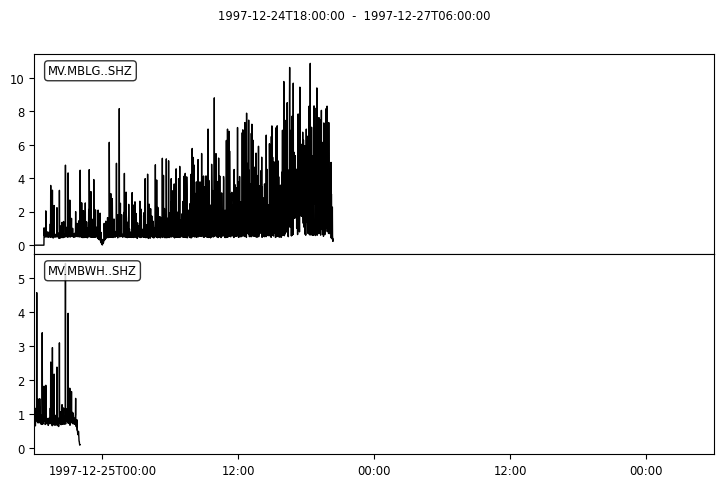

Computing surface-wave DRS in the VLP band


In [33]:
startt1 = UTCDateTime(1997,12,24,18,0,0)
endt1 = UTCDateTime(1997,12,27,6,0,0)
mySDSclient = EnhancedSDSClient(SDS_MVO_ROOT)
st3 = mySDSclient.get_waveforms(
    network="MV",
    station="*",
    location="*",
    channel="SHZ",
    starttime=startt1,
    endtime=endt1, 
)
st3.merge()
print(st3)

import numpy as np
from obspy import Stream
st4 = Stream(traces=[tr for tr in st3 if tr.stats.channel == 'SHZ'])
print(st3)
inv = read_inventory(stationxml)
for tr in st3:
    tr.data = np.nan_to_num(tr.data, nan=0) # Ensure data is in float64 format for remove_response
st3.remove_response(inventory=inv, pre_filt=pre_filt, output="DISP") 
st3.plot();

# Generate a Displacement Seismic Amplitude Measurement (DSAM) object - units must be 'm' else will not work
dsamObj = DSAM(stream=st3, sampling_interval=60)

# Define a source location for Soufriere Hills volcano. Station distances to this lat/lon are used to "reduce" the displacement to 1 km distance.
source1 = {'lat':16.71111, 'lon':-62.17722}

# Generate a Reduced Displacement object, assuming body waves (surfaceWaves=False) and no inelastic attenuation (Q=None)

DRobj = dsamObj.compute_reduced_displacement(inv, source, surfaceWaves=False, Q=None)
DRobj.plot()
# Event name
eventname1 = 'Boxing Day Collapse 1997'

#dsamObj1 = DSAM.read(startt1, endt1, SAM_DIR, sampling_interval=60, ext='pickle', trace_ids=['MV.MBWH..SHZ', 'MV.MBLG..SHZ'])
compute_reduced_displacements(eventname1, dsamObj1, source1, stationxml, resultsDF)

In this example, for the regular passband, we get very similar values of $D_R$ and $D_{RS}$ - both around 217 ${cm}^2$. In the VLP passband, the signal is 10 times smaller, which isn't surprising as the only stations available had short-period seismometers.

### 3.2 July 12th 2003 Dome collapse, Montserrat
On July 12th, 2003, over 200 million ${m}^3$ of the lava dome collapse in a series of explosions and pyroclastic flows, over a few hours. Let's compare the $D_R$ (and $D_{RS}$) of this event to the Boxing Day 1997 collapse we just examined. Since this collapse happened mostly down the Tar River Valley, we will pick a source location there, rather than one centred on the lava dome.

Dataframe with 360 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 360 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 360 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 360 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 360 rows is already on a regular 60 s grid based on column 'time'
Computing body-wave DR
SCAFFOLD: Inventory created at 2024-01-11T03:20:26.394930Z
	Created by: ObsPy 1.4.0
		    https://www.obspy.org
	Sending institution: ObsPy's obspy.io.xseed version 1.2.2
	Contains:
		Networks (54):
			MV (54x)
		Stations (75):
			MV.MBBE () (3x)
			MV.MBBY () (6x)
			MV.MBFL () (3x)
			MV.MBFR () (3x)
			MV.MBGA () (3x)
			MV.MBGB () (6x)
			MV.MBGE () (3x)
			MV.MBGH () (9x)
			MV.MBHA () (3x)
			MV.MBLG () (6x)
			MV.MBLY () (6x)
			MV.MBMH () (3x)
			MV.MBRV () (3x)
			MV.MBRY () (9x)
			MV.MBSS () (3x)
			MV.MBWH () (6x)
		Channels (75):
			MV.MBBE..BHZ, MV.MBB

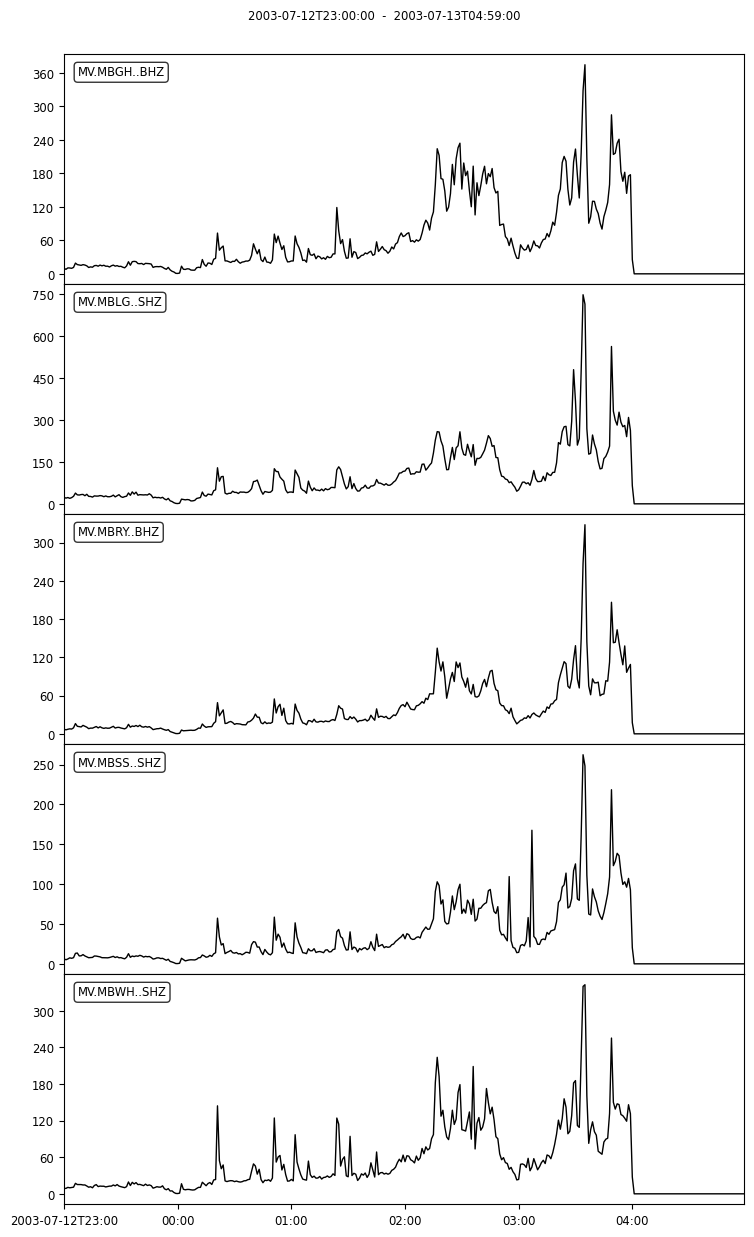

Computing surface-wave DRS
SCAFFOLD: Inventory created at 2024-01-11T03:20:26.394930Z
	Created by: ObsPy 1.4.0
		    https://www.obspy.org
	Sending institution: ObsPy's obspy.io.xseed version 1.2.2
	Contains:
		Networks (54):
			MV (54x)
		Stations (75):
			MV.MBBE () (3x)
			MV.MBBY () (6x)
			MV.MBFL () (3x)
			MV.MBFR () (3x)
			MV.MBGA () (3x)
			MV.MBGB () (6x)
			MV.MBGE () (3x)
			MV.MBGH () (9x)
			MV.MBHA () (3x)
			MV.MBLG () (6x)
			MV.MBLY () (6x)
			MV.MBMH () (3x)
			MV.MBRV () (3x)
			MV.MBRY () (9x)
			MV.MBSS () (3x)
			MV.MBWH () (6x)
		Channels (75):
			MV.MBBE..BHZ, MV.MBBE..BHN, MV.MBBE..BHE, MV.MBBY..BHZ, 
			MV.MBBY..BHN, MV.MBBY..BHE, MV.MBBY..HHZ, MV.MBBY..HHN, 
			MV.MBBY..HHE, MV.MBFL..EHZ, MV.MBFL..EHN, MV.MBFL..EHE, 
			MV.MBFR..HHZ, MV.MBFR..HHN, MV.MBFR..HHE, MV.MBGA..BHZ, 
			MV.MBGA..BHN, MV.MBGA..BHE, MV.MBGB..BHZ, MV.MBGB..BHN, 
			MV.MBGB..BHE, MV.MBGB..HHZ, MV.MBGB..HHN, MV.MBGB..HHE, 
			MV.MBGE..BHZ, MV.MBGE..BHN, MV.MBGE..BHE, MV.MBGH..BHZ, 
			M

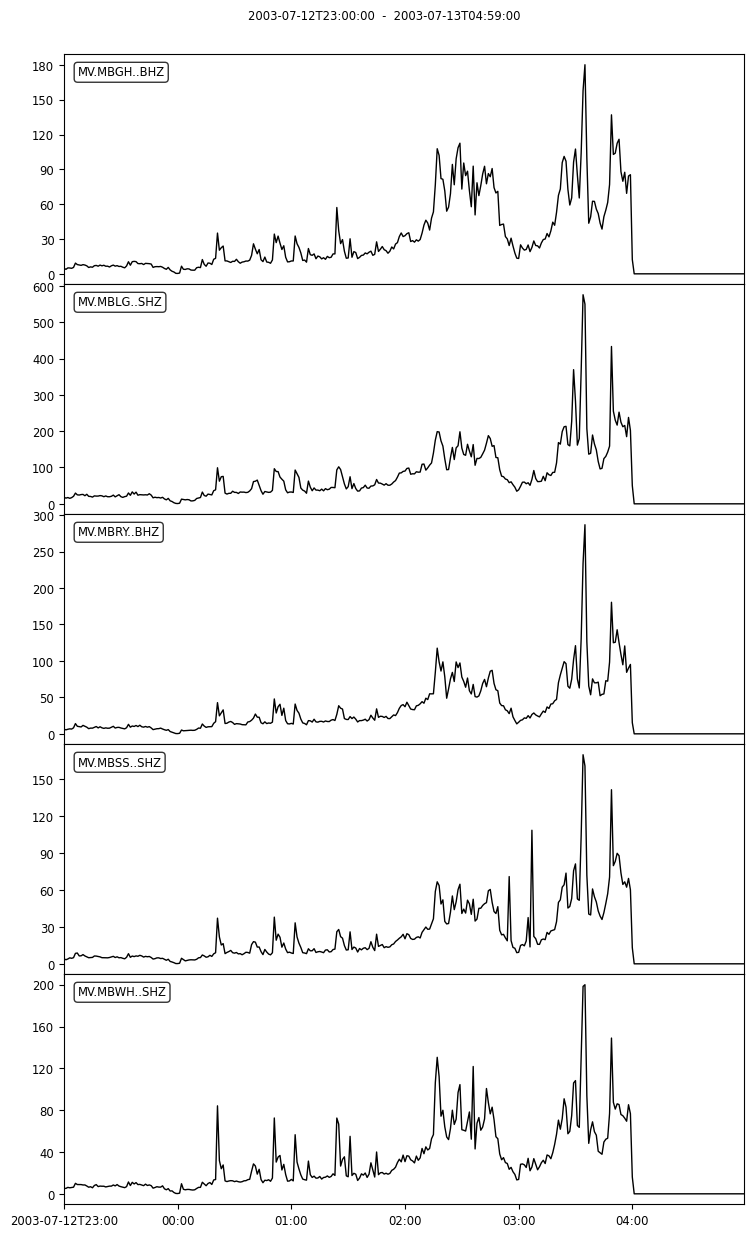

Computing surface-wave DRS in the VLP band


In [11]:
eventname2 = '2003/07/12 collapse, Montserrat'
#stationxml2 = os.path.join(RESPONSE_DIR, 'MV.xml')
source2 = {'lat':16.7164, 'lon':-62.1654}  # Tar River
startt2 = obspy.UTCDateTime(2003,7,12,23,0,0)
endt2 = obspy.UTCDateTime(2003,7,13,5,0,0)
dsamObj2 = DSAM.read(startt2, endt2, SAM_DIR=SAM_DIR, sampling_interval=60, ext='pickle', \
                    trace_ids=['MV.MBGH..BHZ', 'MV.MBLG..SHZ', 'MV.MBRY..BHZ', 'MV.MBSS..SHZ', 'MV.MBWH..SHZ'])
compute_reduced_displacements(eventname2, dsamObj2, source2, stationxml, resultsDF)

### 3.3 Phreatic eruption, Whakaari, Dec 9th, 2019

Whakaari - otherwise known as White Island - is the subaerial tip of a 1600 m high volcano that rises from the seafloor. Tourists arriving by boat and helicopter take a short hike into an open volcanic crater, past fumaroles, to an overlook of the crater lake. Phreatic eruptions are particularly difficult to forecast, as unlike magmatic eruptions, there are no seismic precursors (or indeed any other precuroses) that have been identified. Sadly, this particulary eruption led to the deaths of 22 tourists and guides. Let's compute the $D_R$ (and $D_{RS}$) of this event.


Dataframe with 120 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 120 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 120 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 120 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 120 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 120 rows is already on a regular 60 s grid based on column 'time'
Computing body-wave DR
SCAFFOLD: Inventory created at 2024-01-11T20:32:45.000000Z
	Created by: Delta
		    
	Sending institution: GeoNet (WEL(GNS_Test))
	Contains:
		Networks (1):
			NZ
		Stations (30):
			NZ.028A (Opotiki Shell Service Station)
			NZ.030A (Opotiki Fruit Bowl)
			NZ.113A (Maraenui Primary School)
			NZ.214A (Opotiki Telephone Exchange)
			NZ.214B (Opotiki Shell Service Station)
			NZ.712A (Whakatane High School)
			NZ.932A (Whakatane Council Engineers Office)
			NZ.OPCS (Opotiki College)
			N

/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/obspy/core/inventory/network.py:321: UserWarning: Found more than one matching channel metadata. Returning first.
  warnings.warn(msg)


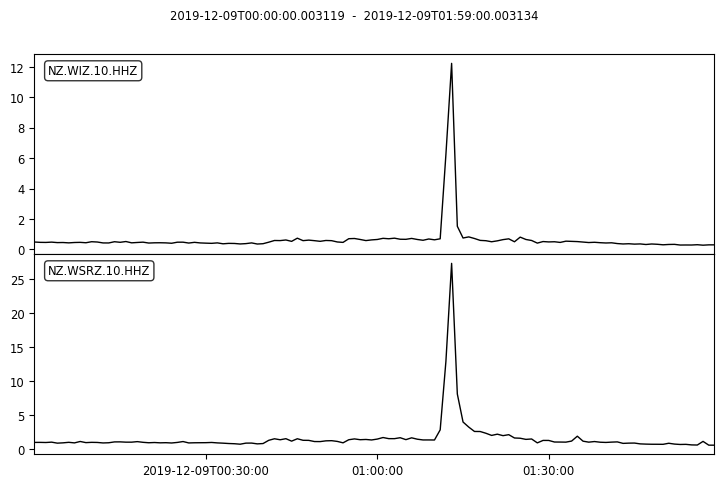

Computing surface-wave DRS
SCAFFOLD: Inventory created at 2024-01-11T20:32:45.000000Z
	Created by: Delta
		    
	Sending institution: GeoNet (WEL(GNS_Test))
	Contains:
		Networks (1):
			NZ
		Stations (30):
			NZ.028A (Opotiki Shell Service Station)
			NZ.030A (Opotiki Fruit Bowl)
			NZ.113A (Maraenui Primary School)
			NZ.214A (Opotiki Telephone Exchange)
			NZ.214B (Opotiki Shell Service Station)
			NZ.712A (Whakatane High School)
			NZ.932A (Whakatane Council Engineers Office)
			NZ.OPCS (Opotiki College)
			NZ.WHRZ (Whale Island)
			NZ.WI01 (White Island 01)
			NZ.WI02 (White Island 02)
			NZ.WI03 (White Island 03)
			NZ.WI04 (White Island 04)
			NZ.WI05 (White Island 05)
			NZ.WI06 (White Island 06)
			NZ.WI07 (White Island 07)
			NZ.WI08 (White Island 08)
			NZ.WI09 (White Island 09)
			NZ.WI10 (White Island 10)
			NZ.WI12 (White Island 12)
			NZ.WI13 (White Island 13)
			NZ.WI14 (White Island 14)
			NZ.WI15 (White Island 15)
			NZ.WI16 (White Island 16)
			NZ.WI17 (White Island 

/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/obspy/core/inventory/network.py:321: UserWarning: Found more than one matching channel metadata. Returning first.
  warnings.warn(msg)


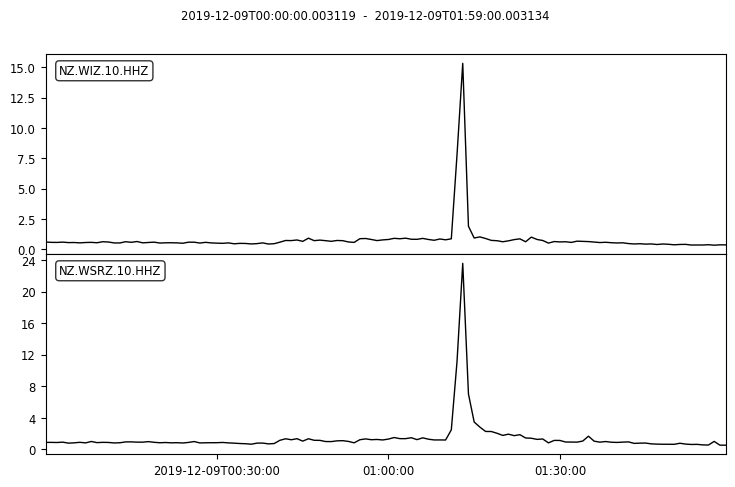

Computing surface-wave DRS in the VLP band


In [12]:
eventname3 = '2019/12/09 Phreatic explosion, Whakaari'
stationxml3 = RESPONSE_DIR / 'NZ.xml'
source3 = {'lat':-37.5217, 'lon':177.185}
startt3 = obspy.UTCDateTime(2019,12,9,0,0,0)
endt3 = obspy.UTCDateTime(2019,12,9,2,0,0)
dsamObj3 = DSAM.read(startt3, endt3, SAM_DIR=SAM_DIR, sampling_interval=60, ext='pickle')
compute_reduced_displacements(eventname3, dsamObj3, source3, stationxml3, resultsDF)

So this was a much smaller event - a $D_R$ (and $D_{RS}$)  of ~20 ${cm}^2$. It was also short in duration - just a few minutes long. But tourist groups inside the crater stood no chance.

### 3.4 Sub-Plinian eruption of Redoubt volcano, March 23, 2009

Redoubt volcano in Alaska had been in a state of unrest for 2-3 months, with deep-long-period earthquakes, deformation, swarms, and tremor, before explosively erupting at least 18 times between March 23rd and March 28th, 2009. We look only at March 23rd. There were actually 5 major explosive events on this day, which began at 6:38am (18,000 ft), 7:02am (44,000 ft), 08:14am (43,000 ft), 9:39am (43,000 ft), and 12:31pm (49,000 ft). 

The seismic data come from an analog telemetry system, and most channels are heavily contaminated by large interference spikes, and if we don't remove these, we'll end up with $D_R$   of ~10^7 ${cm}^2$ !! It turns out there are only two stations free of this noise, RDN and REF, although these also become contaminated from around 3pm onwards.

The seismograms look clean, so now we'll compute the DSAM data and apply a clip level of 0.01 mm to the displacement seismogram. This might take 1-2 minutes because it is computing DSAM data for 24 hours of multi-channel data.

Dataframe with 540 rows is already on a regular 60 s grid based on column 'time'
Dataframe with 540 rows is already on a regular 60 s grid based on column 'time'
Computing body-wave DR
SCAFFOLD: Inventory created at 2024-01-12T14:33:10.079300Z
	Created by: IRIS WEB SERVICE: fdsnws-station | version: 1.1.52
		    http://service.iris.edu/fdsnws/station/1/query?starttime=2008-01-...
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (2):
			AV, SY
		Stations (38):
			AV.BGR (Barrier Glacier Two, regional station, Alaska)
			AV.DFR (Drift River, Redoubt, Alaska)
			AV.ILI (Iliamna Volcano, Alaska)
			AV.ILW (Iliamna West, Iliamna Volcano, Alaska)
			AV.INE (Iliamna North East, Iliamna Volcano, Alaska)
			AV.IVE (Iliamna Volcano East, Iliamna Volcano, Alaska)
			AV.NCT (North Crescent, Redoubt Volcano, Alaska)
			AV.RD01 (Broadband 01, Redoubt, Alaska)
			AV.RD02 (Broadband 02, Redoubt, Alaska)
			AV.RD03 (Broadband 03, Redoubt, Alaska)
			AV.RDDR (Drift River, Redoubt Volcano,

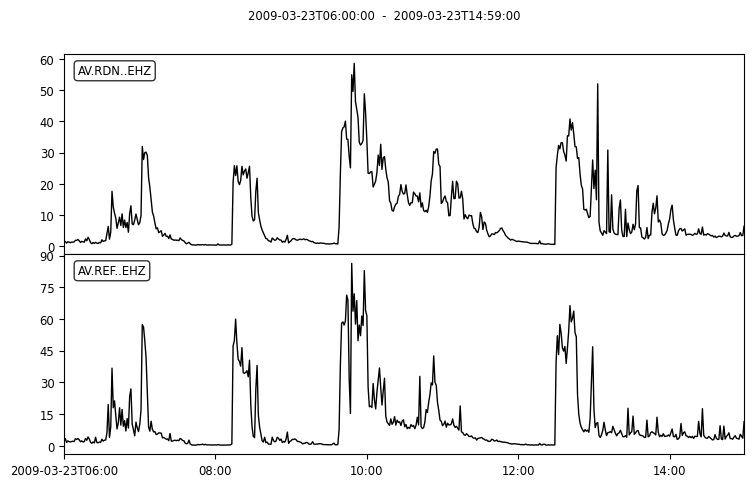

Computing surface-wave DRS
SCAFFOLD: Inventory created at 2024-01-12T14:33:10.079300Z
	Created by: IRIS WEB SERVICE: fdsnws-station | version: 1.1.52
		    http://service.iris.edu/fdsnws/station/1/query?starttime=2008-01-...
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (2):
			AV, SY
		Stations (38):
			AV.BGR (Barrier Glacier Two, regional station, Alaska)
			AV.DFR (Drift River, Redoubt, Alaska)
			AV.ILI (Iliamna Volcano, Alaska)
			AV.ILW (Iliamna West, Iliamna Volcano, Alaska)
			AV.INE (Iliamna North East, Iliamna Volcano, Alaska)
			AV.IVE (Iliamna Volcano East, Iliamna Volcano, Alaska)
			AV.NCT (North Crescent, Redoubt Volcano, Alaska)
			AV.RD01 (Broadband 01, Redoubt, Alaska)
			AV.RD02 (Broadband 02, Redoubt, Alaska)
			AV.RD03 (Broadband 03, Redoubt, Alaska)
			AV.RDDR (Drift River, Redoubt Volcano, Alaska)
			AV.RDE (East, Redoubt Volcano, Alaska)
			AV.RDJH (Juergen's Hut, Redoubt Volcano, Alaska)
			AV.RDN (North, Redoubt Volcano, Alaska)
			AV.RDT (R

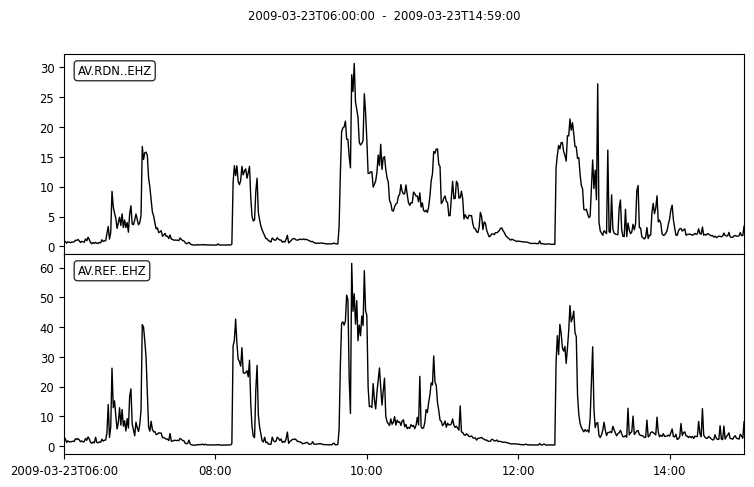

Computing surface-wave DRS in the VLP band


In [13]:
startt4 = obspy.UTCDateTime(2009,3,23,6,0,0)
endt4 = obspy.UTCDateTime(2009,3,23,15,0,0)
dsamObj4 = DSAM.read(startt4, endt4, SAM_DIR=SAM_DIR, sampling_interval=60, ext='pickle', \
                     trace_ids=['AV.RDN..EHZ', 'AV.REF..EHZ'])
eventname4 = '2009/03/23 Redoubt Sub-Plinian eruptions'
stationxml4 = RESPONSE_DIR / 'RD.xml'
source4 = {'lat':60.4845, 'lon':-152.7392}
compute_reduced_displacements(eventname4, dsamObj4, source4, stationxml4, resultsDF)

### 3.5 Hunga Tonga eruption, Jan 15th, 2022

Our final example is Hunga Tonga, which on January 15th, 2022, exploded spectacularly, destroying most of the island, generating a tsunami, and seismic, pressure and gravity waves that propagated around the globe several times. 

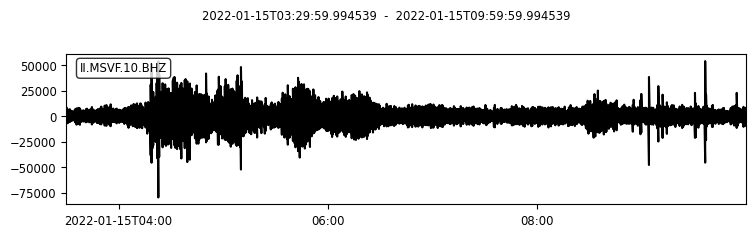

In [14]:
from obspy.clients.filesystem.sds import Client as sdsclient
eventname5 = 'Hunga Tonga, 2022/01/15'
mySDSclient = sdsclient(DATA_ROOT / "SDS_Hunga")
startt5 = obspy.UTCDateTime(2022,1,15,3,30,0)
endt5 = obspy.UTCDateTime(2022,1,15,10,0,0)
st = mySDSclient.get_waveforms("II", "MSVF", "10", "BHZ", startt5, endt5)
st.plot(equal_scale=False);

Computing body-wave DR
SCAFFOLD: Inventory created at 2024-01-18T21:08:04.434800Z
	Created by: IRIS WEB SERVICE: fdsnws-station | version: 1.1.52
		    http://service.iris.edu/fdsnws/station/1/query?starttime=2022-01-...
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (6):
			AU, G, II, IU, MH, SY
		Stations (18):
			AU.NIUE (Niue Island, Niue)
			G.FUTU (Maopo'opo, Futuna)
			II.MSVF (Monasavu, Fiji)
			IU.AFI (Afiamalu, Samoa)
			IU.RAO (Raoul, Kermadec Islands)
			MH.P0006 (MERMAIDHydrophone)
			MH.P0007 (MERMAIDHydrophone)
			MH.P0008 (MERMAIDHydrophone)
			SY.AFI (AFI synthetic)
			SY.FUTU (FUTU synthetic)
			SY.LEON (LEON synthetic)
			SY.LEOS (LEOS synthetic)
			SY.MSVF (MSVF synthetic)
			SY.NIUE (NIUE synthetic)
			SY.NOAA (NOAA synthetic)
			SY.RAO (RAO synthetic)
			SY.SAVE (SAVE synthetic)
			SY.SAVW (SAVW synthetic)
		Channels (200):
			AU.NIUE..AX0, AU.NIUE..BHZ, AU.NIUE..BHN, AU.NIUE..BHE, 
			AU.NIUE..LCE, AU.NIUE..LCQ, AU.NIUE..VCO, AU.NIUE..VEA, 
			AU

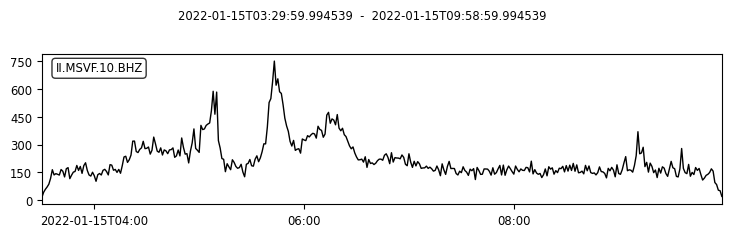

Computing surface-wave DRS
SCAFFOLD: Inventory created at 2024-01-18T21:08:04.434800Z
	Created by: IRIS WEB SERVICE: fdsnws-station | version: 1.1.52
		    http://service.iris.edu/fdsnws/station/1/query?starttime=2022-01-...
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (6):
			AU, G, II, IU, MH, SY
		Stations (18):
			AU.NIUE (Niue Island, Niue)
			G.FUTU (Maopo'opo, Futuna)
			II.MSVF (Monasavu, Fiji)
			IU.AFI (Afiamalu, Samoa)
			IU.RAO (Raoul, Kermadec Islands)
			MH.P0006 (MERMAIDHydrophone)
			MH.P0007 (MERMAIDHydrophone)
			MH.P0008 (MERMAIDHydrophone)
			SY.AFI (AFI synthetic)
			SY.FUTU (FUTU synthetic)
			SY.LEON (LEON synthetic)
			SY.LEOS (LEOS synthetic)
			SY.MSVF (MSVF synthetic)
			SY.NIUE (NIUE synthetic)
			SY.NOAA (NOAA synthetic)
			SY.RAO (RAO synthetic)
			SY.SAVE (SAVE synthetic)
			SY.SAVW (SAVW synthetic)
		Channels (200):
			AU.NIUE..AX0, AU.NIUE..BHZ, AU.NIUE..BHN, AU.NIUE..BHE, 
			AU.NIUE..LCE, AU.NIUE..LCQ, AU.NIUE..VCO, AU.NIUE..VEA, 
	

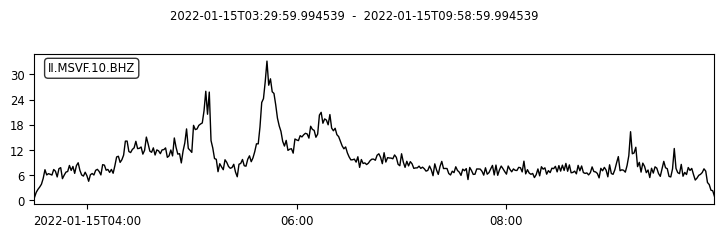

Computing surface-wave DRS in the VLP band


In [15]:
pre_filt = [0.04, 0.05, 18, 25]
stationxml5 = RESPONSE_DIR  / 'II.xml'
inv = obspy.read_inventory(stationxml5)
st.remove_response(inventory=inv, pre_filt=pre_filt, output="DISP", plot=False) 

#################################################
# So far we just have a displacement seismogram
#################################################

# Generate a Displacement Seismic Amplitude Measurement (DSAM) object - units must be 'm' else will not work
dsamObj5 = DSAM(stream=st, sampling_interval=60)

source5 = {'lat':-20.57, 'lon':-175.38}

compute_reduced_displacements(eventname5, dsamObj5, source5, stationxml5, resultsDF, surfaceWaveSpeed_kms=3.0)

## 4. Results

In [16]:
display(resultsDF)

,Event,DR,DRS,DRS_VLP
0,Boxing Day Collapse 1997,12.52,8.16,0.00
1,"2003/07/12 collapse, Montserrat",342.74,199.99,1900.34
2,"2019/12/09 Phreatic explosion, Whakaari",19.75,19.46,525.09
3,2009/03/23 Redoubt Sub-Plinian eruptions,72.45,46.06,0.00
4,"Hunga Tonga, 2022/01/15",751.43,33.18,39142.69


Which values are reasonable to accept?
- For event 0, there were only short-period seismometers available, so the VLP-band results should be ignored. Since we are at local distances, we expect body waves to dominate, so we choose $D_R$ over $D_{RS}$ and accept 218 ${cm}^2$.
- For event 1, while broadband seismometers were available, the VLP-band results are lower. Again, we prefer $D_R$ over $D_{RS}$, since we are at local distances, so we accept 342 ${cm}^2$.
- For event 2, while the VLP bands show higher results, Whakaari is a small island, so the VLP energy likely comes from ocean noise. Again, we are at the local scale, so we accept 18.8 ${cm}^2$.
- For event 3, Redoubt is coastal, and we are at local distances, so we choose $D_R$, and accept 64 ${cm}^2$.
- For event 4, station MSVF is about 760 km from Hunga Tonga, so surface waves dominate, and most of the signal is between 0.01 and 0.6 Hz. Is the $D_{RS}^{VLP}$ value of 39,000 ${cm}^2$ reasonable? 

Clearly, we must be very careful applying the same measurements at local, regional, and global scales!

#### CAVEAT: We ignored inelastic attenuation in this analysis. Including it would make Reduced Displacement estimates even higher!

Finally, there is a sort of "magnitude scale" for volcanic eruptions called the Volcanic Explosivity Index (VEI), which similar to earthquake magnitude scales, runs from about 1 to 8. However, VEI is not an instrumental measurement, and instead is estimated from the volume of deposits found, and the height an ash column reaches, and other things. Hunga Tonga was estimated by different researchers to be either a VEI=5 or VEI=6 eruption, so if we fix that at VEI=5.5 and throw caution to the wind, here are instrumental VEI estimates for the other events above too:

In [17]:
import numpy as np
correction = 5.5 - np.log10(39142.68)
for DR  in [218.12, 341.51, 18.82, 64.02, 39142.68]:
    VEI = np.log10(DR) + correction
    print(f'DR={DR:.1f}, VEI={VEI:.1f}')

DR=218.1, VEI=3.2
DR=341.5, VEI=3.4
DR=18.8, VEI=2.2
DR=64.0, VEI=2.7
DR=39142.7, VEI=5.5


They do actually seem quite reasonable! :-p